[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Average daily return: nan
Volatility (risk): nan
Sharpe Ratio: nan


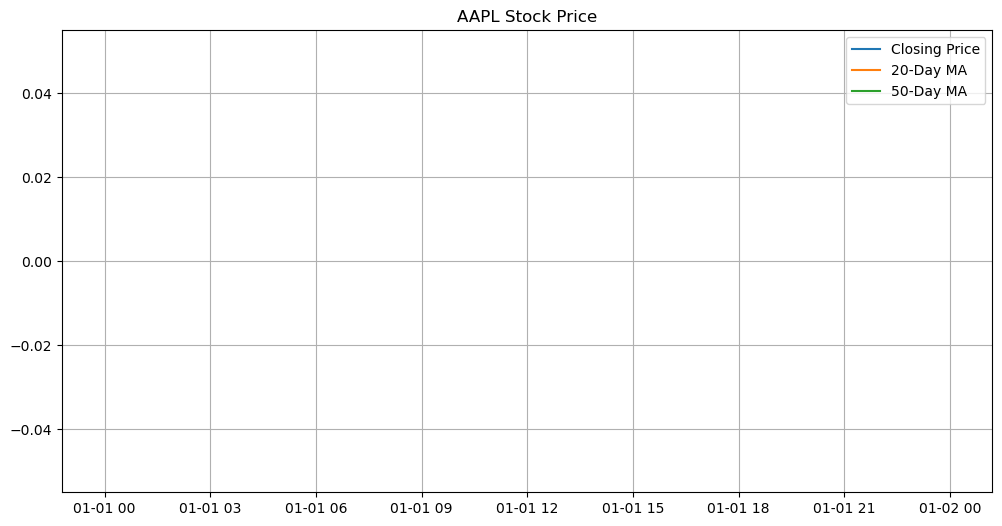

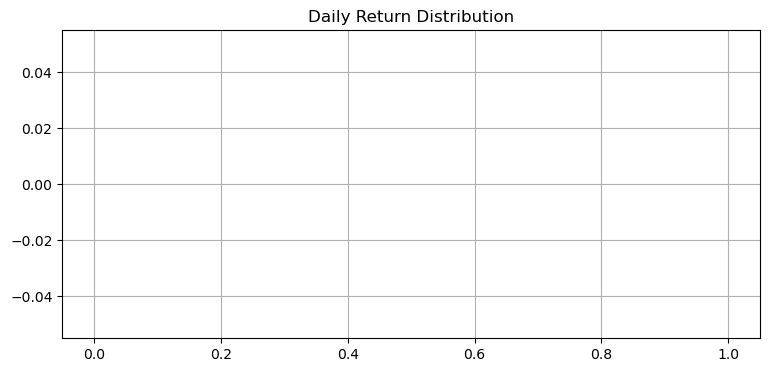

interactive(children=(Dropdown(description='stock', options=('AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN'), value='…

<function __main__.analyze(stock)>

In [12]:
# %% [markdown]
# # Stock Analysis Tool
# ## Mingyang Liu | 2471001
# Track 4 - Interactive Data Analysis

# %% [markdown]
# # 1. Project Overview

# ## Analytical Problem
# Many beginner investors do not have simple tools to evaluate stock performance and risk.
# This project aims to analyse stock prices, returns, and volatility using Python.

# ## Objective
# - Analyse stock price trends
# - Measure return and risk
# - Provide simple interactive analysis

# %% [markdown]
# ## Data Source
# Data is obtained from Yahoo Finance using the yfinance package.
# Access date: April 2026.

# %%
# Install required libraries
!pip install yfinance ipywidgets

# %%
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# %% [markdown]
# # 2. Get Stock Data
# I will use Apple (AAPL) as an example stock from 2020 to 2024.

# %%
# Download data
stock = "AAPL"
data = yf.download(stock, start="2020-01-01", end="2024-01-01")

# Show first rows
data.head()

# %% [markdown]
# # 3. Clean and Prepare Data

# %%
# Remove missing values
data = data.dropna()

# Calculate daily return
data["Return"] = data["Close"].pct_change()

# Add moving averages
data["MA20"] = data["Close"].rolling(window=20).mean()
data["MA50"] = data["Close"].rolling(window=50).mean()

data.head()

# %% [markdown]
# # 4. Basic Statistics (Return and Risk)

# %%
mean_return = data["Return"].mean()
volatility = data["Return"].std()

# Add simple performance metric (轻微加分点)
risk_free_rate = 0.0001
sharpe_ratio = (mean_return - risk_free_rate) / volatility

print("Average daily return:", mean_return)
print("Volatility (risk):", volatility)
print("Sharpe Ratio:", sharpe_ratio)

# %% [markdown]
# # 5. Visualize Stock Price and Trends

# %%
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Closing Price")
plt.plot(data["MA20"], label="20-Day MA")
plt.plot(data["MA50"], label="50-Day MA")

plt.title(f"{stock} Stock Price")
plt.legend()
plt.grid(True)
plt.show()

# %%
plt.figure(figsize=(9,4))
plt.hist(data["Return"].dropna(), bins=50)
plt.title("Daily Return Distribution")
plt.grid(True)
plt.show()

# %% [markdown]
# # 6. Interactive Stock Analyzer
# Users can choose different stocks to analyse.

# %%
def analyze(stock):
    data = yf.download(stock, start="2020-01-01")
    data = data.dropna()
    
    data["Return"] = data["Close"].pct_change()
    data["MA20"] = data["Close"].rolling(20).mean()
    data["MA50"] = data["Close"].rolling(50).mean()
    
    mean_ret = data["Return"].mean()
    vol = data["Return"].std()
    
    # Add Sharpe ratio in interactive part
    risk_free_rate = 0.0001
    sharpe = (mean_ret - risk_free_rate) / vol
    
    print(f"Stock: {stock}")
    print(f"Mean return: {mean_ret}")
    print(f"Volatility: {vol}")
    print(f"Sharpe Ratio: {sharpe}")
    
    plt.figure(figsize=(12,6))
    plt.plot(data["Close"], label="Close Price")
    plt.plot(data["MA20"], label="MA20")
    plt.plot(data["MA50"], label="MA50")
    plt.title(stock + " Price Chart")
    plt.legend()
    plt.grid(True)
    plt.show()

# %%
# Interactive menu
widgets.interact(
    analyze,
    stock=["AAPL", "TSLA", "MSFT", "GOOGL", "AMZN"]
)

# %% [markdown]
# # 7. Conclusion

# ## Findings
# - AAPL shows relatively stable growth over the selected period.
# - Stocks such as TSLA tend to have higher volatility.
# - Moving averages help identify trends.

# ## Insights
# - Higher return is usually associated with higher risk.
# - Volatility is an important measure for investors.

# ## Limitations
# - Only historical data is used
# - No prediction model is included

# ## Future Improvements
# - Add forecasting models
# - Include more indicators
# - Improve interactivity